In [1]:
!pip install pandas scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score, confusion_matrix

In [10]:
from google.colab import files
uploaded = files.upload()

Saving world_war_3_dataset.csv to world_war_3_dataset.csv


In [20]:
df = pd.read_csv("world_war_3_dataset.csv")
df.head()

,tweet_id,tweet_text,sentiment
0,1,I am concerned that diplomacy might fail this ...,negative
1,2,There is still hope that negotiations will res...,positive
2,3,I am concerned that diplomacy might fail this ...,negative
3,4,History shows that not every tension leads to ...,positive
4,5,People worldwide prefer stability and cooperat...,positive


In [21]:
print(df.shape)

(100, 3)


In [22]:
print(df["sentiment"].unique())

['negative' 'positive' 'neutral']


In [23]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [24]:
df["clean_text"] = df["tweet_text"].apply(clean_text)
df.head()

,tweet_id,tweet_text,sentiment,clean_text
0,1,I am concerned that diplomacy might fail this ...,negative,i am concerned that diplomacy might fail this ...
1,2,There is still hope that negotiations will res...,positive,there is still hope that negotiations will res...
2,3,I am concerned that diplomacy might fail this ...,negative,i am concerned that diplomacy might fail this ...
3,4,History shows that not every tension leads to ...,positive,history shows that not every tension leads to ...
4,5,People worldwide prefer stability and cooperat...,positive,people worldwide prefer stability and cooperat...


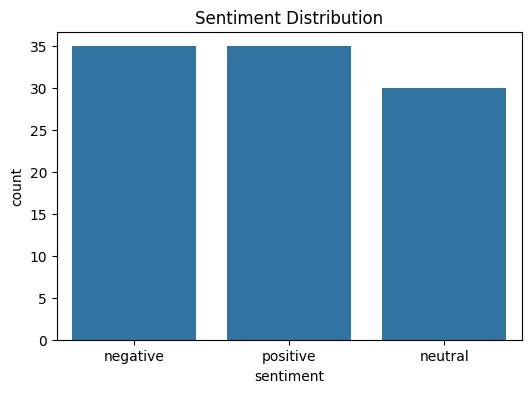

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

In [26]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=20, random_state=42, stratify=y
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 80
Test: 20


In [27]:
vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [28]:
models = {
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(kernel="linear"),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy
    })

    print(f"\n{name}")
    print(classification_report(y_test, y_pred, zero_division=0))


Naive Bayes
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


SVM
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Logistic Regression
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00   

In [29]:
results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,Accuracy
0,Naive Bayes,1.0,1.0,1.0
1,SVM,1.0,1.0,1.0
2,Logistic Regression,1.0,1.0,1.0


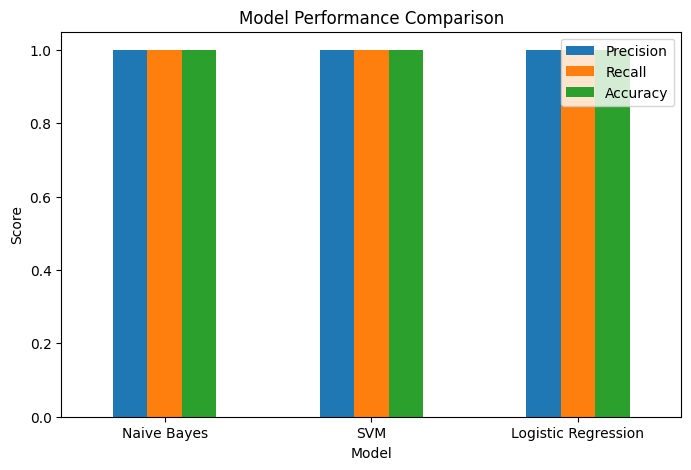

In [30]:
results_df.plot(x="Model", y=["Precision", "Recall", "Accuracy"], kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

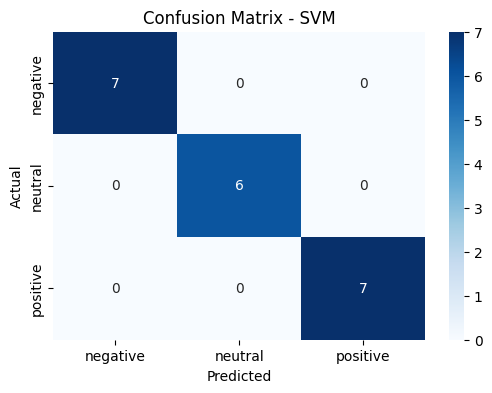

In [31]:
best_model = SVC(kernel="linear")
best_model.fit(X_train_vec, y_train)
y_pred_best = best_model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

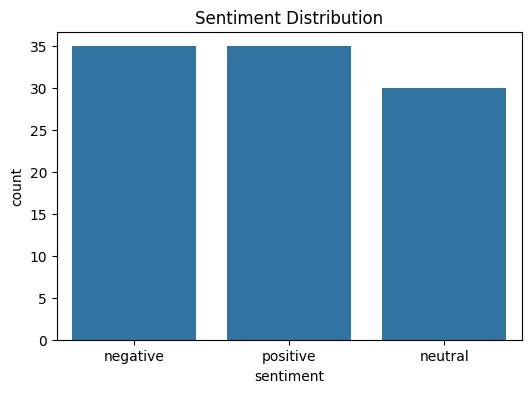

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.savefig("sentiment_distribution.png")
plt.show()